In [1]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets

In [2]:
X.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States


In [3]:
y['income'].unique()

<StringArray>
['<=50K', '>50K', '<=50K.', '>50K.']
Length: 4, dtype: str

In [4]:
y['income'] = y['income'].replace({'<=50K.':'<=50K', '>50K.':'>50K'})

In [5]:
encoding_y = {'<=50K':0, '>50K':1}
y['income'] = y['income'].map(encoding_y)

In [6]:
print(f'Number of NA: {X.isna().any(axis=1).sum()}')

Number of NA: 1221


In [7]:
idx_na = X.index[X.isna().any(axis=1)]
X.dropna(inplace=True)
y.drop(idx_na, inplace=True)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

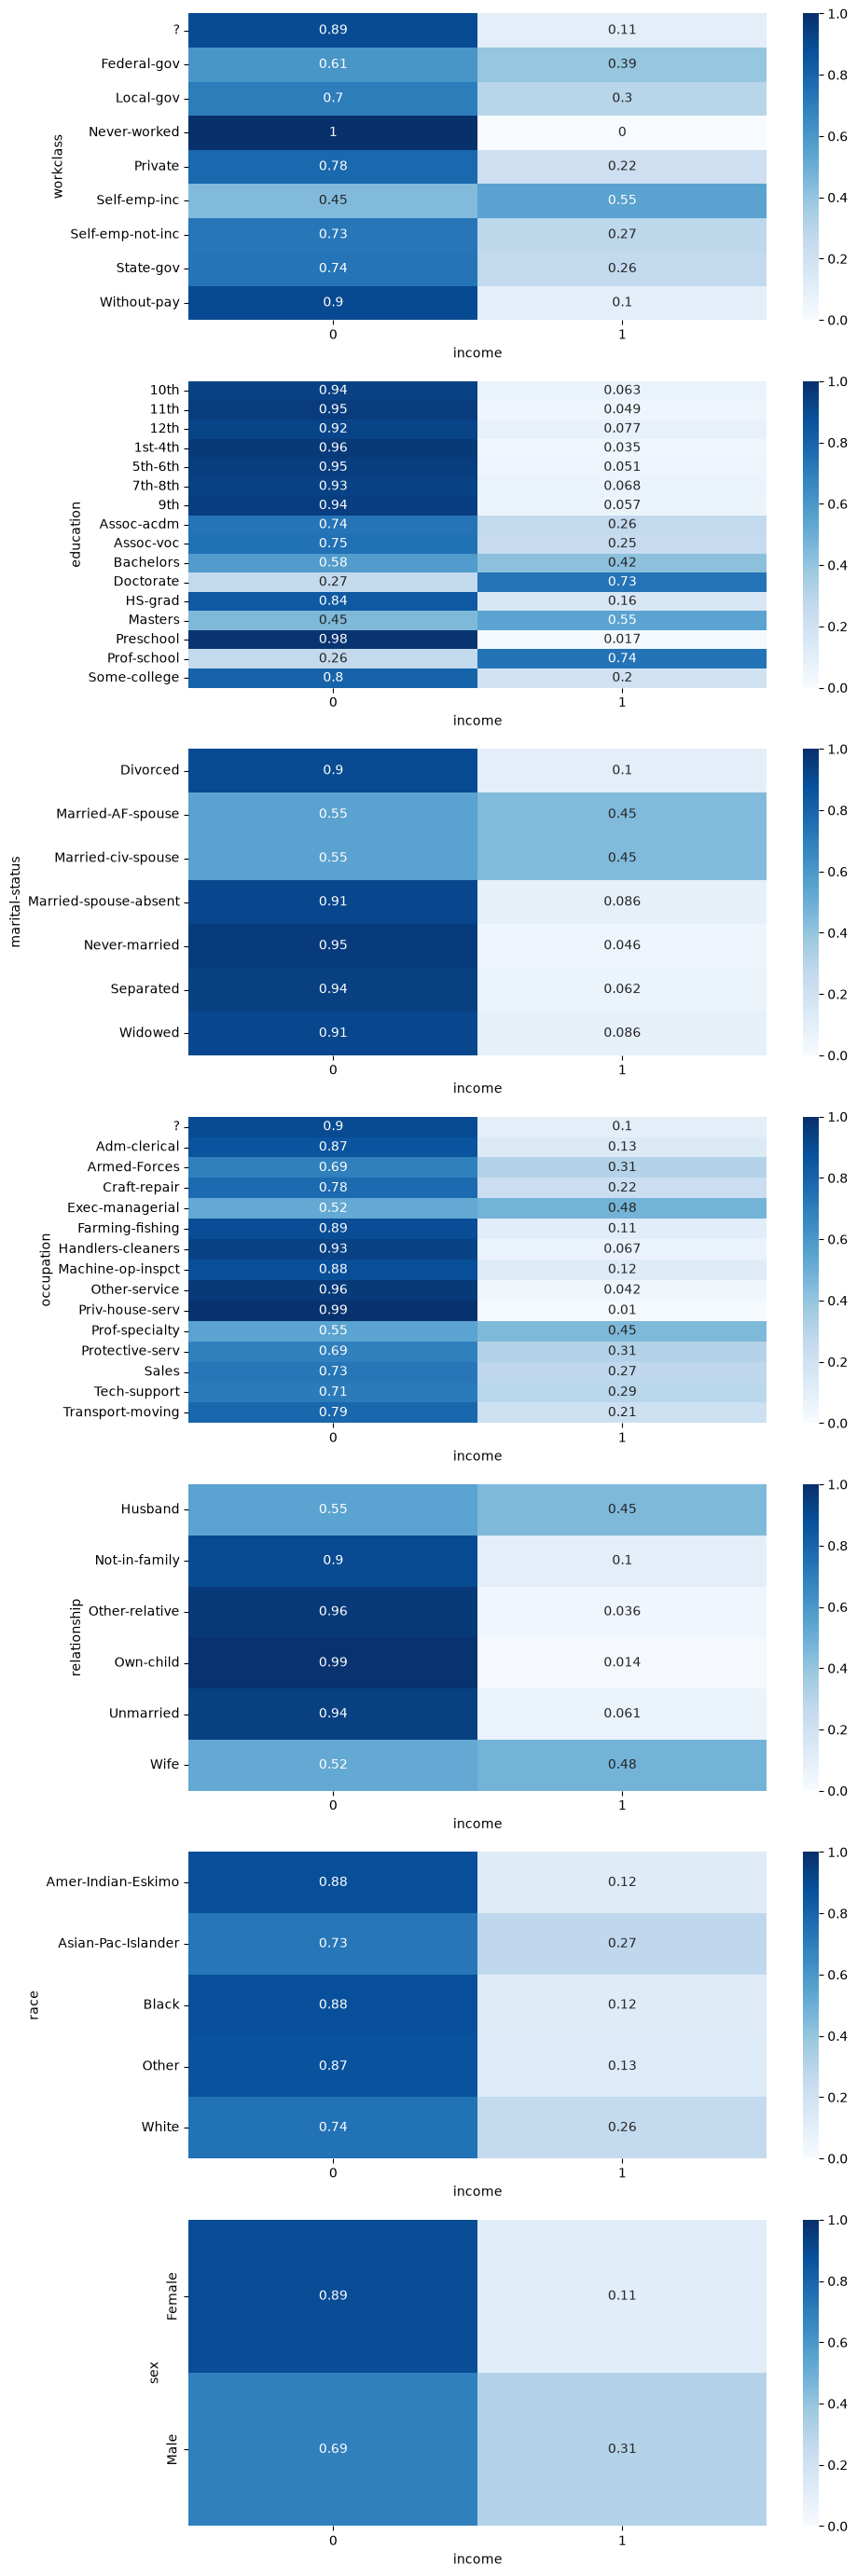

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['workclass', 'education', 'marital-status', 
        'occupation', 'relationship', 'race', 'sex']

fig, ax = plt.subplots(len(cols), 1, figsize = (10, 35))
i = 0
for i, col in enumerate(cols):
    ct = pd.crosstab(X_train[col], y_train['income'], normalize='index')
    sns.heatmap(ct, annot=True, cmap='Blues', vmin=0, vmax=1, ax=ax[i])
plt.show()

In [10]:
cols = ['workclass', 'education', 'marital-status', 
        'occupation', 'relationship', 'race', 'sex',
       'native-country']

for col in cols:
    encoding = (y_train['income'] == '>50K').groupby(X_train[col]).mean()
    X_train[col] = X_train[col].map(encoding)
    X_test[col] = X_test[col].map(encoding)

In [11]:
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    max_depth = trial.suggest_int('max_depth', 50, 500)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_leaf_nodes = trial.suggest_int('max_leaf_nodes', 20, 500)

    tree = DecisionTreeClassifier(
        max_depth = max_depth,
        min_samples_split = min_samples_split,
        min_samples_leaf = min_samples_leaf,
        max_leaf_nodes = max_leaf_nodes,
        random_state = 42
    )

    score = cross_val_score(estimator = tree,
                            X = X_train, 
                            y = y_train, 
                            cv=4, scoring='accuracy').mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=500)
    

[I 2026-07-17 16:17:25,630] A new study created in memory with name: no-name-569d5baf-4749-4eb1-9413-2e82348729a9
[I 2026-07-17 16:17:25,839] Trial 0 finished with value: 0.8301396472070559 and parameters: {'max_depth': 152, 'min_samples_split': 17, 'min_samples_leaf': 1, 'max_leaf_nodes': 206}. Best is trial 0 with value: 0.8301396472070559.
[I 2026-07-17 16:17:26,076] Trial 1 finished with value: 0.8217660646787064 and parameters: {'max_depth': 397, 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_leaf_nodes': 449}. Best is trial 0 with value: 0.8301396472070559.
[I 2026-07-17 16:17:26,285] Trial 2 finished with value: 0.8265697186056278 and parameters: {'max_depth': 494, 'min_samples_split': 14, 'min_samples_leaf': 10, 'max_leaf_nodes': 293}. Best is trial 0 with value: 0.8301396472070559.
[I 2026-07-17 16:17:26,475] Trial 3 finished with value: 0.8305333893322133 and parameters: {'max_depth': 406, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_leaf_nodes': 191}. Best is tr

In [12]:
tree = DecisionTreeClassifier(**study.best_params)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score

accuracy_score(y_pred, y_test)

0.829501312335958

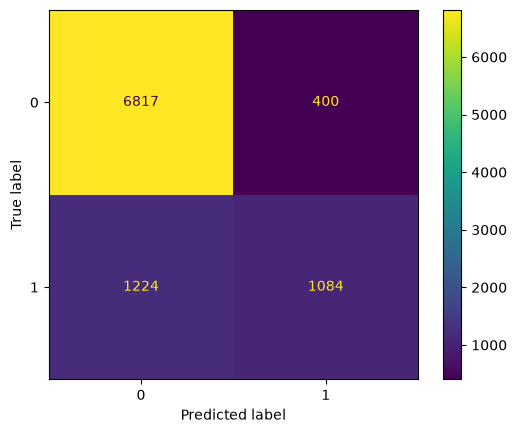

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

In [47]:
import xgboost
from sklearn.model_selection import StratifiedKFold
    
def objective(trial):
    params = {
        'n_estimators' : trial.suggest_int('n_estimators', 50, 500),
        'max_depth' : trial.suggest_int('max_depth', 5, 12),
        'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'gamma' : trial.suggest_float('gamma', 0.01, 0.4),
        'reg_lambda' : trial.suggest_float('reg_lambda', 1, 10, log=True),
        'reg_alpha' : trial.suggest_float('reg_alpha', 0.001, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.8, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1)}
    
    xgb = xgboost.XGBClassifier(
        **params,
        random_state = 42
    )
    cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

    score = cross_val_score(estimator = xgb,
                            X = X_train, 
                            y = y_train, 
                            cv=cv, scoring='f1_weighted').mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

[I 2026-07-17 17:43:38,115] A new study created in memory with name: no-name-a2403cfb-d375-4dee-9e91-f9d2d1e1b0dc
[I 2026-07-17 17:43:39,917] Trial 0 finished with value: 0.8286653776468249 and parameters: {'n_estimators': 265, 'max_depth': 8, 'learning_rate': 0.03224108316537883, 'gamma': 0.05548009774805963, 'reg_lambda': 1.0884201130778328, 'reg_alpha': 0.14871189559435358, 'subsample': 0.8428072979652663, 'colsample_bytree': 0.9034281568806967}. Best is trial 0 with value: 0.8286653776468249.
[I 2026-07-17 17:43:40,724] Trial 1 finished with value: 0.813576398458832 and parameters: {'n_estimators': 167, 'max_depth': 6, 'learning_rate': 0.018540544249250467, 'gamma': 0.03492890423387006, 'reg_lambda': 9.995784785247698, 'reg_alpha': 0.001186695188698081, 'subsample': 0.8033133502412989, 'colsample_bytree': 0.528837315111011}. Best is trial 0 with value: 0.8286653776468249.
[I 2026-07-17 17:43:41,240] Trial 2 finished with value: 0.824652521928534 and parameters: {'n_estimators': 74,

In [48]:
xgb = xgboost.XGBClassifier(**study.best_params, random_state=42)
xgb.fit(X_train, y_train)
print(f'Best value: {study.best_value}')

Best value: 0.8303896799424688


In [50]:
from sklearn.ensemble import RandomForestClassifier
    
def objective(trial):
    params = {
        'n_estimators' : trial.suggest_int('n_estimators', 50, 500),
        'max_depth' : trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 8),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
    }
    
    rfc = RandomForestClassifier(
        **params,
        random_state = 42
    )
    cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

    score = cross_val_score(estimator = xgb,
                            X = X_train, 
                            y = y_train, 
                            cv=cv, scoring='f1_weighted').mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

[I 2026-07-17 17:52:48,091] A new study created in memory with name: no-name-5bf27dd8-f50b-4add-a987-7e3250575447
[I 2026-07-17 17:52:50,381] Trial 0 finished with value: 0.8303896799424688 and parameters: {'n_estimators': 494, 'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.8303896799424688.
[I 2026-07-17 17:52:52,203] Trial 1 finished with value: 0.8303896799424688 and parameters: {'n_estimators': 318, 'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.8303896799424688.
[I 2026-07-17 17:52:54,790] Trial 2 finished with value: 0.8303896799424688 and parameters: {'n_estimators': 340, 'max_depth': 23, 'min_samples_split': 8, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.8303896799424688.
[I 2026-07-17 17:52:56,855] Trial 3 finished with value: 0.8303896799424688 and parameters: {'n_estimators': 380, 'max_depth': 16, 'min_samples_split': 6, 'min_samples_leaf': 2}. Best is trial 0 with value:

In [55]:
rfc = RandomForestClassifier(**study.best_params, random_state=42)
rfc.fit(X_train, y_train)
print(f'Best value: {study.best_value}')

/home/piq/Projects/data_science_projects/.venv/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best value: 0.8303896799424688


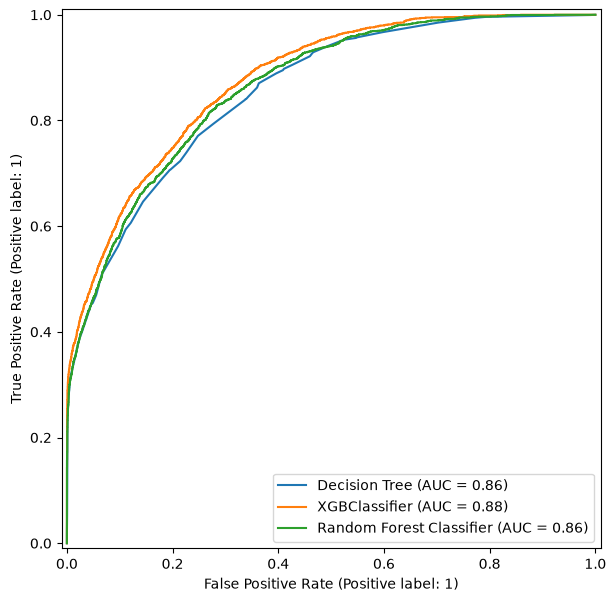

In [56]:
from sklearn.metrics import roc_curve
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize = (7,7))

RocCurveDisplay.from_estimator(tree, X_test, y_test, ax=ax, name='Decision Tree')
RocCurveDisplay.from_estimator(xgb, X_test, y_test, ax=ax, name='XGBClassifier')
RocCurveDisplay.from_estimator(rfc, X_test, y_test, ax=ax, name='Random Forest Classifier')
plt.show()

In [59]:
from sklearn.metrics import accuracy_score

y_pred = rfc.predict(X_test)
accuracy_score(y_pred, y_test)

0.8325459317585302

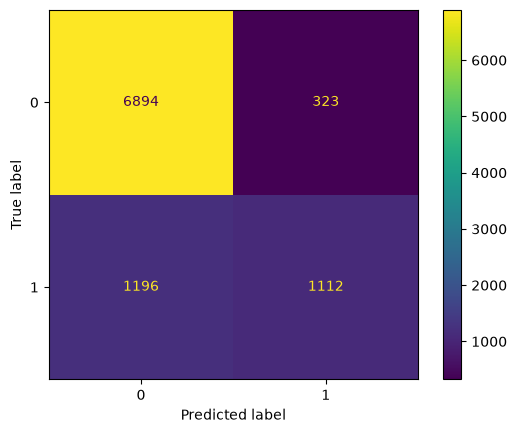

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = xgb.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()